In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import time
import copy
import random
import numpy as np
import os
from concurrent.futures import ThreadPoolExecutor

NUM_GPUS = torch.cuda.device_count()
print(f"Доступно GPU: {NUM_GPUS}")

Доступно GPU: 8


### Загрузка данных

В качестве датасета возьмем простенький CIFAR10 — датасет с цветными картинками 32x32 с 10 классами

In [2]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

testloader = DataLoader(testset, batch_size=1000, shuffle=False)

### Выбор модели для демонстрации разных подходов

А все-таки будем выпендриваться и возьмем resnet-14, чтобы хоть как-то подзагрузить gpu

Точность будем замерять с помощью accuracy

In [3]:
def evaluate_model(model, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [4]:
import pynvml
import threading
import time
import matplotlib.pyplot as plt

class GPUProfiler:
    def __init__(self, gpu_ids, interval=0.05):
        """
        Фоновый профилировщик загрузки GPU.
        interval: как часто опрашивать GPU (в секундах). 0.05 = 20 раз в секунду.
        """
        pynvml.nvmlInit()
        self.gpu_ids = gpu_ids
        self.interval = interval
        self.handles = [pynvml.nvmlDeviceGetHandleByIndex(i) for i in gpu_ids]
        self.running = False
        self.data = {i: [] for i in gpu_ids}
        self.timestamps = []

    def _monitor(self):
        while self.running:
            self.timestamps.append(time.time() - self.start_time)
            for i, handle in enumerate(self.handles):
                # Получаем загрузку ядра GPU в процентах (0-100%)
                util = pynvml.nvmlDeviceGetUtilizationRates(handle).gpu
                self.data[self.gpu_ids[i]].append(util)
            time.sleep(self.interval)

    def start(self):
        self.data = {i: [] for i in self.gpu_ids}
        self.timestamps = []
        self.running = True
        self.start_time = time.time()
        self.thread = threading.Thread(target=self._monitor)
        self.thread.start()

    def stop(self):
        self.running = False
        self.thread.join()

    def plot(self, title="Загрузка GPU во времени"):
        plt.figure(figsize=(12, 4))
        max_load = 5
        for gpu_id in self.gpu_ids:
            plt.plot(self.timestamps, self.data[gpu_id], label=f'GPU {gpu_id}', alpha=0.8)
            max_load = max(max_load, max(self.data[gpu_id]))
        plt.title(title)
        plt.xlabel('Время (секунды)')
        plt.ylabel('Загрузка ядра GPU (%)')
        plt.ylim(0, max_load+5)
        plt.grid(True)
        plt.legend(loc='upper right')
        plt.show()

In [5]:
N_EPOCH = 10

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### Эксперимент 1

В качестве самого первого эксперимента посмотрим, на что способна одна H100.

Обучим модель классическим способом (Single Node, Single GPU) за несколько эпох. Запомним время и итоговую точность.

--- Эксперимент 1: Обучение на 1x H100 ---
Эпоха 1 | Loss: 1.388 | Точность: 58.88%
Эпоха 2 | Loss: 0.976 | Точность: 66.54%
Эпоха 3 | Loss: 0.793 | Точность: 67.87%
Эпоха 4 | Loss: 0.664 | Точность: 69.89%
Эпоха 5 | Loss: 0.559 | Точность: 68.56%
Эпоха 6 | Loss: 0.457 | Точность: 71.47%
Эпоха 7 | Loss: 0.377 | Точность: 71.73%
Эпоха 8 | Loss: 0.299 | Точность: 73.30%
Эпоха 9 | Loss: 0.251 | Точность: 72.51%
Эпоха 10 | Loss: 0.193 | Точность: 73.39%
Время обучения на 1 GPU: 60.81 секунд



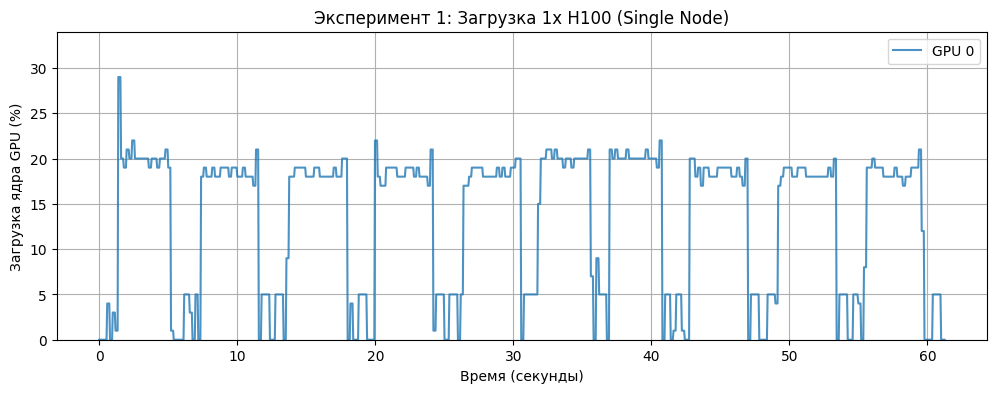

In [6]:
print("--- Эксперимент 1: Обучение на 1x H100 ---")
seed_everything()
profiler_single = GPUProfiler(gpu_ids=[0]) # Следим только за cuda:0
profiler_single.start()

device_single = torch.device("cuda:0")
model_single = torchvision.models.resnet18(num_classes=10).to(device_single)
criterion = nn.CrossEntropyLoss()
optimizer_single = optim.Adam(model_single.parameters(), lr=0.001)

trainloader_single = DataLoader(trainset, batch_size=256, shuffle=True, num_workers=8, pin_memory=True)

start_time = time.time()

for epoch in range(N_EPOCH):
    model_single.train()
    running_loss = 0.0
    for inputs, labels in trainloader_single:
        inputs, labels = inputs.to(device_single), labels.to(device_single)

        optimizer_single.zero_grad()
        outputs = model_single(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_single.step()

        running_loss += loss.item()

    acc = evaluate_model(model_single, device_single)
    print(f"Эпоха {epoch+1} | Loss: {running_loss/len(trainloader_single):.3f} | Точность: {acc:.2f}%")

single_time = time.time() - start_time
profiler_single.stop()

print(f"Время обучения на 1 GPU: {single_time:.2f} секунд\n")
profiler_single.plot(title="Эксперимент 1: Загрузка 1x H100 (Single Node)")

### Эксперимент 2

Теория из лекции: В архитектуре Parameter Server мы разделяем роли.

Сервер: Мы поместим его на CPU. Он будет хранить "Мастер-модель" и делать шаг оптимизатора.

Воркеры: Это наши 8 H100 (cuda:0 ... cuda:7).

Синхронизация: Мы реализуем строгий BSP (Bulk Synchronous Parallel). Сервер ждет градиенты от всех 8 видеокарт, усредняет их и только потом обновляет веса.

In [7]:
def worker_step(worker_id, inputs, labels):
    device = f"cuda:{worker_id}"
    model = worker_models[worker_id]
    model.train()

    inputs, labels = inputs.to(device), labels.to(device)
    model.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    return loss.item()

--- Эксперимент 2: Parameter Server (1 CPU Server, 8 GPU Workers) ---
Эпоха 1 | Точность: 10.28%
Эпоха 2 | Точность: 10.00%
Эпоха 3 | Точность: 10.00%
Эпоха 4 | Точность: 10.00%
Эпоха 5 | Точность: 10.00%
Эпоха 6 | Точность: 10.00%
Эпоха 7 | Точность: 9.97%
Эпоха 8 | Точность: 10.00%
Эпоха 9 | Точность: 9.99%
Эпоха 10 | Точность: 10.00%

Время обучения на 1 GPU: 60.81 сек
Время Parameter Server (8 GPU): 247.08 сек


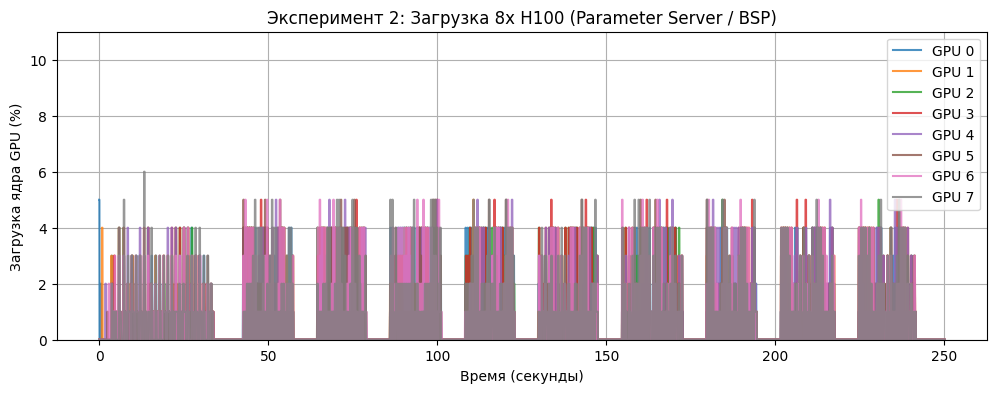

In [8]:
print("--- Эксперимент 2: Parameter Server (1 CPU Server, 8 GPU Workers) ---")
seed_everything()
profiler_ps = GPUProfiler(gpu_ids=list(range(NUM_GPUS))) # Следим за всеми 8 GPU
profiler_ps.start()

# 1. Сервер: Мастер-модель на CPU
server_model = torchvision.models.resnet18(num_classes=10).cpu()
server_optimizer = optim.Adam(server_model.parameters(), lr=0.001)

# 2. Воркеры: 8 моделей на 8 GPU
worker_models = [torchvision.models.resnet18(num_classes=10).to(f"cuda:{i}") for i in range(NUM_GPUS)]

# 3. Делим данные на 8 непересекающихся кусков
chunk_size = len(trainset) // NUM_GPUS
worker_loaders = []
for i in range(NUM_GPUS):
    indices = list(range(i * chunk_size, (i + 1) * chunk_size))
    subset = Subset(trainset, indices)
    worker_loaders.append(DataLoader(subset, batch_size=256, shuffle=True))

start_time_ps = time.time()

for epoch in range(N_EPOCH):
    # Создаем итераторы для каждого воркера
    iterators = [iter(loader) for loader in worker_loaders]
    step_count = 0

    while True:
        try:
            # Берем по одному батчу для каждого воркера
            batches = [next(it) for it in iterators]
        except StopIteration:
            break # Эпоха закончилась

        # --- ШАГ 1: BROADCAST (Server -> Workers) ---
        # Сервер рассылает актуальные веса всем воркерам (CPU -> GPU)
        master_state = server_model.state_dict()
        for i in range(NUM_GPUS):
            worker_models[i].load_state_dict(master_state)

        # --- ШАГ 2: COMPUTE (Workers) ---
        # Запускаем расчет градиентов параллельно на 8 H100
        with ThreadPoolExecutor(max_workers=NUM_GPUS) as executor:
            futures = [executor.submit(worker_step, i, batches[i][0], batches[i][1]) for i in range(NUM_GPUS)]
            [f.result() for f in futures] # Ждем всех (BSP стратегия)

        # --- ШАГ 3: AGGREGATION & PULL (Workers -> Server) ---
        server_optimizer.zero_grad()

        # Ручное усреднение градиентов
        for server_param, worker_params in zip(server_model.parameters(), zip(*[m.parameters() for m in worker_models])):
            # Собираем градиенты с GPU на CPU и усредняем
            avg_grad = torch.stack([wp.grad.cpu() for wp in worker_params]).mean(dim=0)
            server_param.grad = avg_grad

        # --- ШАГ 4: OPTIMIZER STEP (Server) ---
        server_optimizer.step()
        step_count += 1

    acc = evaluate_model(server_model, "cpu")
    print(f"Эпоха {epoch+1} | Точность: {acc:.2f}%")

ps_time = time.time() - start_time_ps
profiler_ps.stop()
print(f"\nВремя обучения на 1 GPU: {single_time:.2f} сек")
print(f"Время Parameter Server ({NUM_GPUS} GPU): {ps_time:.2f} сек")
profiler_ps.plot(title="Эксперимент 2: Загрузка 8x H100 (Parameter Server / BSP)")

### Эксперимент 3

Теперь представим, что наши 8 GPU — это не сервер в дата-центре, а 8 разных больниц (или 8 смартфонов).
Сеть между ними медленная и дорогая. Мы не можем пересылать градиенты на каждом батче.

Идея алгоритма FedAvg:
1. Сервер отправляет модель клиентам.
1. Каждый клиент учится на своих данных целую эпоху (Local Training).
1. Клиенты возвращают серверу новые веса (а не градиенты).
1. Сервер усредняет веса.

In [9]:
print("--- Эксперимент 3: Federated Learning (FedAvg) ---")
seed_everything()
profiler_fl = GPUProfiler(gpu_ids=list(range(NUM_GPUS))) # Следим за всеми 8 GPU
profiler_fl.start()

# Сервер (Мастер-модель)
fl_server_model = torchvision.models.resnet18(num_classes=10).cpu()

# Воркеры (Устройства клиентов)
fl_worker_models = [torchvision.models.resnet18(num_classes=10).to(f"cuda:{i}") for i in range(NUM_GPUS)]

start_time_fl = time.time()

# В Federated Learning мы говорим не про "эпохи", а про "Раунды связи" (Communication Rounds)
NUM_ROUNDS = N_EPOCH

for round_num in range(NUM_ROUNDS):
    print(f"--- Раунд {round_num + 1} ---")

    # 1. Сервер рассылает веса клиентам (Broadcast)
    master_state = fl_server_model.state_dict()
    for i in range(NUM_GPUS):
        fl_worker_models[i].load_state_dict(master_state)

    def client_train(client_id):
        device = f"cuda:{client_id}"
        model = fl_worker_models[client_id]
        loader = worker_loaders[client_id]
        # У каждого клиента свой локальный оптимизатор!
        optimizer = optim.Adam(model.parameters(), lr=0.001) 
        model.train()

        # Клиент делает ПОЛНУЮ эпоху на своих данных (в тайне от сервера)
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # 2. Клиенты обучаются локально (параллельно)
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(client_train, i) for i in range(NUM_GPUS)]
        [f.result() for f in futures]

    # 3. Сервер собирает веса от клиентов и усредняет их (Aggregation)
    worker_states = [m.state_dict() for m in fl_worker_models]
    averaged_state = copy.deepcopy(master_state)

    for key in averaged_state.keys():
        # Собираем тензоры с GPU на CPU и усредняем
        tensors = [state[key].cpu() for state in worker_states]
        averaged_state[key] = torch.stack(tensors).mean(dim=0)

    # 4. Сервер обновляет глобальную модель
    fl_server_model.load_state_dict(averaged_state)

    acc = evaluate_model(fl_server_model, "cpu")
    print(f"Точность глобальной модели: {acc:.2f}%")

fl_time = time.time() - start_time_fl
profiler_fl.stop()

print(f"Время обучения FedAvg: {fl_time:.2f} сек")
profiler_fl.plot(title="Эксперимент 3: Загрузка 8x H100 (Federated Learning / FedAvg)")

--- Эксперимент 3: Federated Learning (FedAvg) ---
--- Раунд 1 ---


RuntimeError: mean(): could not infer output dtype. Input dtype must be either a floating point or complex dtype. Got: Long